In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier

In [2]:
circle = pd.read_csv("circle_seq.csv")
guide = pd.read_csv("guide-seq.csv")

In [3]:
guide = guide.rename(columns={
    'crRNA': 'sgRNA_seq',
    'DNA': 'off_seq',
    'read': 'read_count'
})

circle = circle.rename(columns={
    'Read_normalised': 'read_count'
})


In [4]:
data = pd.concat([circle, guide], ignore_index=True)
data = data[['sgRNA_seq','off_seq','label','read_count']]
data = data.dropna()


In [5]:
data

,sgRNA_seq,off_seq,label,read_count
0,G_AGTCCGAGCAGAAGAAGAAAGG,GGAGTCCGTGCAGAAGCAGGAAGC,0.0,0.0
1,G_AGTCCGAGCAGAAGAAGAAAGG,CAAGTCCGAGAAGAAGCAGAAAAG,0.0,0.0
2,G_AGTCCGAGCAGAAGAAGAAAGG,GAAGTCTTAGCAAAAGAAGAAAGC,0.0,0.0
3,G_AGTCCGAGCAGAAGAAGAAAGG,GAAGTCCGAGGAGAGGAAGAAAGG,0.0,0.0
4,G_AGTCCGAGCAGAAGAAGAAAGG,GAAGGCGGAGAAGAAGAAGAAATT,0.0,0.0
...,...,...,...,...
798877,-GATGGTAGATGGAGACTCAGTGG,-G_TGGTAGAAGGAGACTCTGTGG,1.0,10.0
798878,-GCTTCCGTTGCTTAGCTCTGAGG,-GAT_CAGTTGCCTAGCTCTGAGG,1.0,3.0
798879,-GCCCTGCTGCCCCAGTTCGAGGG,-TCCCTGCAGCCCCAGTTC_AGGG,1.0,17.0
798880,-GCCGGAGGGGTTTGCACAGAAGG,-GA_GGAGGGGTTTGCACAGGAGG,1.0,3070.0


In [6]:
def one_hot(seq):
    mapping = {'A':[1,0,0,0],
               'T':[0,1,0,0],
               'G':[0,0,1,0],
               'C':[0,0,0,1]}
    
    seq = str(seq).upper()
    
    return np.array([
        mapping.get(base, [0,0,0,0]) 
        for base in seq
    ]).flatten()



In [7]:
def mismatch_count(sg, off):
    return sum(1 for a,b in zip(sg,off) if a!=b)


In [8]:
print(data['sgRNA_seq'].iloc[144])
print(data['off_seq'].iloc[144])

print(mismatch_count(
    data['sgRNA_seq'].iloc[144],
    data['off_seq'].iloc[144]
))


GAGTCCGA_GCAGAAGAAGAACGG
GAGGCTGAGGCAGAAGAATAACTT
6


In [9]:
print(len(data['sgRNA_seq'].iloc[144]))
print(len(data['off_seq'].iloc[144]))


24
24


In [10]:
def gc_content(seq):
    return (seq.count('G') + seq.count('C')) / len(seq)


In [11]:
print(data['sgRNA_seq'].iloc[0])
print(gc_content(data['sgRNA_seq'].iloc[0]))


G_AGTCCGAGCAGAAGAAGAAAGG
0.5


In [12]:
all_chars = set("".join(data['sgRNA_seq'].astype(str)))
print(all_chars)


{'T', 'C', '-', 'G', 'A', '_'}


In [13]:
data['sgRNA_enc'] = data['sgRNA_seq'].apply(one_hot)
data['off_enc'] = data['off_seq'].apply(one_hot)

data['mismatch'] = data.apply(
    lambda x: mismatch_count(x['sgRNA_seq'], x['off_seq']),
    axis=1
)
data['mismatch'] = data['mismatch'] / 24

data['gc'] = data['sgRNA_seq'].apply(gc_content)
data['read_log'] = np.log1p(data['read_count'])



In [14]:
data

,sgRNA_seq,off_seq,label,read_count,sgRNA_enc,off_enc,mismatch,gc,read_log
0,G_AGTCCGAGCAGAAGAAGAAAGG,GGAGTCCGTGCAGAAGCAGGAAGC,0.0,0.0,"[0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...","[0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, ...",0.208333,0.500000,0.000000
1,G_AGTCCGAGCAGAAGAAGAAAGG,CAAGTCCGAGAAGAAGCAGAAAAG,0.0,0.0,"[0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...",0.208333,0.500000,0.000000
2,G_AGTCCGAGCAGAAGAAGAAAGG,GAAGTCTTAGCAAAAGAAGAAAGC,0.0,0.0,"[0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...",0.208333,0.500000,0.000000
3,G_AGTCCGAGCAGAAGAAGAAAGG,GAAGTCCGAGGAGAGGAAGAAAGG,0.0,0.0,"[0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...",0.125000,0.500000,0.000000
4,G_AGTCCGAGCAGAAGAAGAAAGG,GAAGGCGGAGAAGAAGAAGAAATT,0.0,0.0,"[0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...","[0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...",0.250000,0.500000,0.000000
...,...,...,...,...,...,...,...,...,...
798877,-GATGGTAGATGGAGACTCAGTGG,-G_TGGTAGAAGGAGACTCTGTGG,1.0,10.0,"[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, ...",0.125000,0.500000,2.397895
798878,-GCTTCCGTTGCTTAGCTCTGAGG,-GAT_CAGTTGCCTAGCTCTGAGG,1.0,3.0,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, ...",0.166667,0.541667,1.386294
798879,-GCCCTGCTGCCCCAGTTCGAGGG,-TCCCTGCAGCCCCAGTTC_AGGG,1.0,17.0,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",0.125000,0.708333,2.890372
798880,-GCCGGAGGGGTTTGCACAGAAGG,-GA_GGAGGGGTTTGCACAGGAGG,1.0,3070.0,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, ...",0.125000,0.625000,8.029759


In [15]:
def one_hot_2d(seq):
    mapping = {
        'A':[1,0,0,0],
        'T':[0,1,0,0],
        'G':[0,0,1,0],
        'C':[0,0,0,1]
    }
    return np.array([mapping.get(i,[0,0,0,0]) for i in seq])

data['combined_seq'] = data['sgRNA_seq'] + data['off_seq']

X_seq = np.array(
    data['combined_seq'].apply(one_hot_2d).tolist()
)

print("X_seq Shape:", X_seq.shape)


X_seq Shape: (798882, 48, 4)


In [16]:
def mismatch_count(sg, off):
    return sum(1 for a,b in zip(sg,off) if a!=b)

def gc_content(seq):
    return (seq.count('G') + seq.count('C')) / len(seq)

data['mismatch'] = data.apply(
    lambda x: mismatch_count(x['sgRNA_seq'], x['off_seq']),
    axis=1
)
data['mismatch'] = data['mismatch'] / 24

data['gc'] = data['sgRNA_seq'].apply(gc_content)
data['read_log'] = np.log1p(data['read_count'])

X_manual = data[['mismatch','gc']].values
y = data['label'].values

print("Manual Input Shape:", X_manual.shape)


Manual Input Shape: (798882, 2)


In [17]:
from sklearn.model_selection import train_test_split

X_seq_train, X_seq_test, X_man_train, X_man_test, y_train, y_test = train_test_split(
    X_seq, X_manual, y,
    test_size=0.2,
    random_state=42
)

print("Train Seq Shape:", X_seq_train.shape)
print("Train Manual Shape:", X_man_train.shape)


Train Seq Shape: (639105, 48, 4)
Train Manual Shape: (639105, 2)


In [18]:
X = []

for i in range(len(data)):
    features = np.concatenate([
        data['sgRNA_enc'].iloc[i],
        data['off_enc'].iloc[i],
        [data['mismatch'].iloc[i]],
        [data['gc'].iloc[i]],
        [data['read_log'].iloc[i]]
    ])
    X.append(features)

X = np.array(X)
y = data['label'].values


In [21]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [19]:

from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, Flatten, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

seq_length = X_seq_train.shape[1]

# Sequence Input
seq_input = Input(shape=(seq_length,4))

x = Conv1D(64, 3, activation='relu')(seq_input)
x = MaxPooling1D(2)(x)
x = Conv1D(128, 3, activation='relu')(x)   #  FIXED (removed 'u')
x = MaxPooling1D(2)(x)
x = Flatten()(x)

# Manual Input
manual_input = Input(shape=(2,))

#  Manual features ko importance dene ke liye
m = Dense(32, activation='relu')(manual_input)

# Merge
merged = Concatenate()([x, m])

z = Dense(128, activation='relu')(merged)
z = Dropout(0.4)(z)
z = Dense(64, activation='relu')(z)

# Output
output = Dense(1, activation='sigmoid')(z)

#  FIXED (new line)
model = Model(inputs=[seq_input, manual_input], outputs=output)

# Loss
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        p_t = y_true*y_pred + (1-y_true)*(1-y_pred)
        return alpha * (1-p_t)**gamma * bce
    return loss

# Compile
model.compile(
    optimizer=Adam(0.001),
    loss=focal_loss(),
    metrics=['accuracy']
)

print("Model input shape:", model.input_shape)




Model input shape: [(None, 48, 4), (None, 2)]


In [20]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 48, 4)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 46, 64)            │             832 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d (MaxPooling1D)  │ (None, 23, 64)            │               0 │ conv1d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 21, 128)           │          24,704 │ max_pooling1d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_1               │ (None, 10, 128)           │               0 │ conv1d_1[0][0]             │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 1280)              │               0 │ max_pooling1d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 32)                │              96 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 1312)              │               0 │ flatten[0][0], dense[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 128)               │         168,064 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 64)                │           8,256 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 1)                 │              65 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 202,017 (789.13 KB)

 Trainable params: 202,017 (789.13 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from sklearn.utils import class_weight

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {0: weights[0], 1: weights[1]}
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(0.5046604327522137), 1: np.float64(54.14308708912233)}


In [22]:
print(model.input_shape)
print(X_seq_train.shape)


[(None, 48, 4), (None, 2)]
(639105, 48, 4)


In [23]:
validation_split=0.2


In [24]:
history = model.fit(
    [X_seq_train, X_man_train],
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights
)


Epoch 1/20
7989/7989 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - accuracy: 0.9846 - loss: 0.0037 - val_accuracy: 0.9848 - val_loss: 2.7254e-04
Epoch 2/20
7989/7989 ━━━━━━━━━━━━━━━━━━━━ 53s 7ms/step - accuracy: 0.9813 - loss: 0.0021 - val_accuracy: 0.9852 - val_loss: 2.5722e-04
Epoch 3/20
7989/7989 ━━━━━━━━━━━━━━━━━━━━ 60s 8ms/step - accuracy: 0.9824 - loss: 0.0018 - val_accuracy: 0.9793 - val_loss: 4.0747e-04
Epoch 4/20
7989/7989 ━━━━━━━━━━━━━━━━━━━━ 53s 7ms/step - accuracy: 0.9827 - loss: 0.0017 - val_accuracy: 0.9924 - val_loss: 8.3462e-05
Epoch 5/20
7989/7989 ━━━━━━━━━━━━━━━━━━━━ 63s 8ms/step - accuracy: 0.9825 - loss: 0.0016 - val_accuracy: 0.9724 - val_loss: 7.8667e-04
Epoch 6/20
7989/7989 ━━━━━━━━━━━━━━━━━━━━ 55s 7ms/step - accuracy: 0.9827 - loss: 0.0016 - val_accuracy: 0.9823 - val_loss: 3.0797e-04
Epoch 7/20
7989/7989 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - accuracy: 0.9823 - loss: 0.0015 - val_accuracy: 0.9856 - val_loss: 2.1495e-04
Epoch 8/20
7989/7989 ━━━━━━━━━━━━━━━━━━━━ 52s 6ms/step 

In [25]:
from sklearn.metrics import classification_report

probs = model.predict([X_seq_test, X_man_test])

# Try threshold 0.2 for better recall
pred = (probs > 0.2).astype(int)

print(classification_report(y_test, pred))


4994/4994 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97    158258
         1.0       0.14      0.91      0.24      1519

    accuracy                           0.95    159777
   macro avg       0.57      0.93      0.61    159777
weighted avg       0.99      0.95      0.97    159777



In [29]:
pred = (probs > 0.5).astype(int)
print(classification_report(y_test, pred))


              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99    158258
         1.0       0.38      0.71      0.49      1519

    accuracy                           0.99    159777
   macro avg       0.69      0.85      0.74    159777
weighted avg       0.99      0.99      0.99    159777



In [28]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, probs)

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Best F1:", f1[best_idx])


Best Threshold: 0.7697784
Best F1: 0.5383304890436366


In [29]:
pred = (probs > best_threshold).astype(int)
print(classification_report(y_test, pred))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    158258
         1.0       0.56      0.52      0.54      1519

    accuracy                           0.99    159777
   macro avg       0.78      0.76      0.77    159777
weighted avg       0.99      0.99      0.99    159777



In [30]:
from sklearn.metrics import roc_auc_score, average_precision_score

print("ROC-AUC:", roc_auc_score(y_test, probs))
print("PR-AUC:", average_precision_score(y_test, probs))


ROC-AUC: 0.9780212166113931
PR-AUC: 0.5484319882374579


4994/4994 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


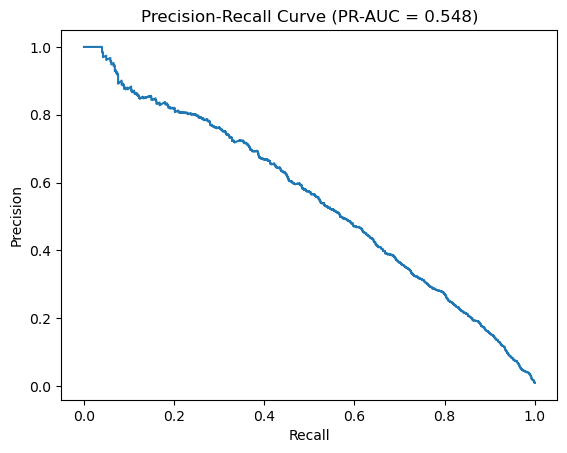

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

probs = model.predict([X_seq_test, X_man_test]).ravel()

precision, recall, _ = precision_recall_curve(y_test, probs)
pr_auc = average_precision_score(y_test, probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (PR-AUC = {pr_auc:.3f})")
plt.show()


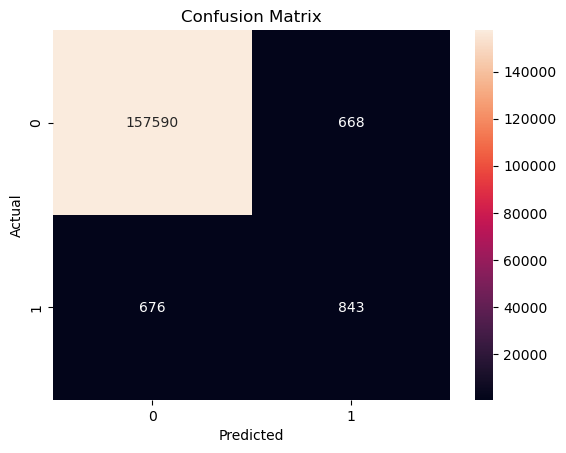

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Best threshold already calculated
pred = (probs > best_threshold).astype(int)

cm = confusion_matrix(y_test, pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [32]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.layers import Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
pr_scores = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_seq, y), 1):
    print(f"\n🔁 Fold {fold}/3 started")

    X_seq_tr, X_seq_te = X_seq[train_idx], X_seq[test_idx]
    X_man_tr, X_man_te = X_manual[train_idx], X_manual[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    # ---- Model ----
    seq_input = Input(shape=(X_seq.shape[1], 4))
    x = Conv1D(32, 3, activation='relu')(seq_input)
    x = MaxPooling1D(2)(x)
    x = Conv1D(64, 3, activation='relu')(x)
    x = MaxPooling1D(2)(x)
    x = Flatten()(x)

    manual_input = Input(shape=(2,))
    merged = Concatenate()([x, manual_input])

    z = Dense(64, activation='relu')(merged)
    z = Dropout(0.3)(z)
    output = Dense(1, activation='sigmoid')(z)

    model = Model([seq_input, manual_input], output)

    model.compile(
        optimizer=Adam(0.001),
        loss=focal_loss(),
        metrics=[]
    )

    model.fit(
        [X_seq_tr, X_man_tr],
        y_tr,
        epochs=2,              # 🔥 SAFE
        batch_size=32,         # 🔥 SAFE
        verbose=1
    )

    probs = model.predict([X_seq_te, X_man_te], verbose=0).ravel()
    pr_auc = average_precision_score(y_te, probs)

    print(f"✅ Fold {fold} PR-AUC: {pr_auc:.4f}")
    pr_scores.append(pr_auc)

    # ---- MEMORY CLEANUP ----
    del model
    tf.keras.backend.clear_session()

print("\n📊 PR-AUC Scores:", pr_scores)
print("📈 Mean PR-AUC:", np.mean(pr_scores))



🔁 Fold 1/3 started
Epoch 1/2
16644/16644 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - loss: 2.6593e-04
Epoch 2/2
16644/16644 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 1.6093e-04
✅ Fold 1 PR-AUC: 0.4394

🔁 Fold 2/3 started
Epoch 1/2
16644/16644 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - loss: 2.7724e-04
Epoch 2/2
16644/16644 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - loss: 1.6513e-04
✅ Fold 2 PR-AUC: 0.4736

🔁 Fold 3/3 started
Epoch 1/2
16644/16644 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step - loss: 2.7572e-04
Epoch 2/2
16644/16644 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - loss: 1.6675e-04
✅ Fold 3 PR-AUC: 0.4241

📊 PR-AUC Scores: [0.4393947721519545, 0.473638014426311, 0.42412661474948216]
📈 Mean PR-AUC: 0.4457198004425826


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X_lr = X_manual   # 🔥 ONLY manual features (mismatch, gc)

X_train, X_test, y_train, y_test = train_test_split(
    X_lr, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        solver="liblinear"   # 🔥 SAFEST
    ))
])

lr_pipeline.fit(X_train, y_train)

probs_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print(
    "Logistic Regression PR-AUC:",
    average_precision_score(y_test, probs_lr)
)




Logistic Regression PR-AUC: 0.062416099173893784


In [26]:
model.save("hybrid_model.h5")

import numpy as np


print("🔥 Model & Threshold Saved Successfully")


🔥 Model & Threshold Saved Successfully


In [27]:
%%writefile app.py


UsageError: %%writefile is a cell magic, but the cell body is empty.
